# Translator Profiles

Workload, quality, punctuality, rate consistency, and schedule patterns at translator level.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


,metric,value
0,Unique translators in task log,983


,TRANSLATOR,task_count
522,Isaias Venancio,65209
971,Xoana,46436
439,Gala,44533
512,Inocencio Lucas,31950
240,Casiano,26149
721,Markel,18538
782,Nieves Leocadia,18375
167,Ascension,17036
801,Oscar,16064
669,Luis Felipe,15122


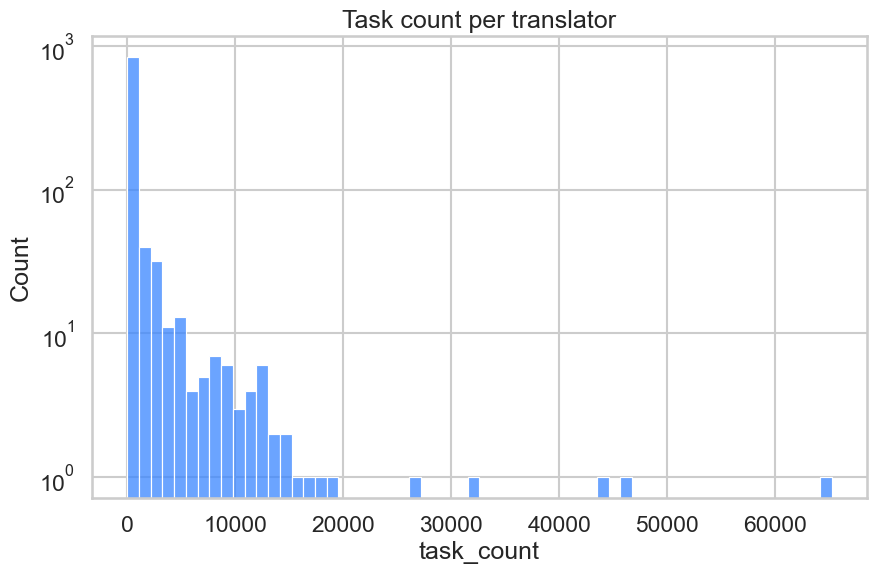

In [2]:
display(pd.DataFrame([{"metric": "Unique translators in task log", "value": data["TRANSLATOR"].nunique()}]))

task_count_per_translator = (
    data.groupby("TRANSLATOR")
    .size()
    .rename("task_count")
    .reset_index()
    .sort_values("task_count", ascending=False)
)
display(task_count_per_translator.head(20))

plt.figure(figsize=(10, 6))
sns.histplot(task_count_per_translator["task_count"], bins=60, color="#3a86ff")
plt.yscale("log")
plt.title("Task count per translator")
plt.show()

,TRANSLATOR,total_hours
0,Severino,38255.51
1,Xoana,31791.10
2,Salma Benedicto,30086.01
3,Ramiro Josafat,29219.43
4,Maximo,24837.92
5,Acacio Poncio,23878.19
6,Laurina Rafael,23503.94
7,Ascension,20239.09
8,Luis Felipe,19835.65
9,Oscar,19292.49


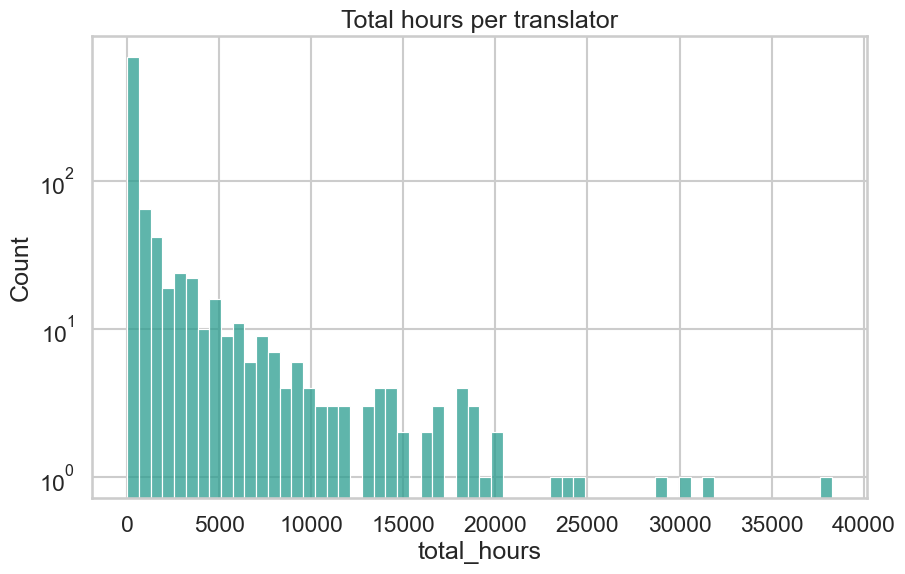

In [3]:
hours_per_translator = (
    data.groupby("TRANSLATOR")["HOURS"]
    .sum()
    .sort_values(ascending=False)
    .rename("total_hours")
    .reset_index()
)
display(hours_per_translator.head(20))

plt.figure(figsize=(10, 6))
sns.histplot(hours_per_translator["total_hours"], bins=60, color="#2a9d8f")
plt.yscale("log")
plt.title("Total hours per translator")
plt.show()

,TRANSLATOR,task_count,total_hours,avg_quality,quality_std,scored_tasks,quality_ci_low,quality_ci_high
522,Isaias Venancio,65209,14862.76,6.937877,1.408113,65209,6.927069,6.948685
971,Xoana,46436,31791.10,6.981997,1.419510,46436,6.969086,6.994908
439,Gala,44533,7137.27,6.944558,1.402847,44533,6.931529,6.957587
512,Inocencio Lucas,31950,17933.58,6.924977,1.423118,31950,6.909372,6.940581
240,Casiano,26149,17052.17,7.024705,1.446592,26149,7.007171,7.042238
721,Markel,18538,8362.35,6.932085,1.413135,18538,6.911743,6.952428
782,Nieves Leocadia,18375,18592.83,6.951673,1.429773,18375,6.931000,6.972347
167,Ascension,17036,20239.09,6.964076,1.414629,17036,6.942833,6.985319
801,Oscar,16064,19292.49,6.978586,1.430901,16064,6.956458,7.000713
669,Luis Felipe,15122,19835.65,7.007869,1.452965,15122,6.984711,7.031028


,TRANSLATOR,task_count,total_hours,avg_quality,quality_std,scored_tasks,quality_ci_low,quality_ci_high
229,Camille,159,267.34,8.993711,1.122254,159,8.819270,9.168152
344,Eduardo,1906,2831.34,8.796432,1.565879,1906,8.726133,8.866732
898,Sara,1879,3647.17,8.758914,1.632306,1879,8.685108,8.832721
472,Guzman,249,348.18,8.746988,1.597705,249,8.548537,8.945439
224,Breixo,2720,2079.11,8.733088,1.302983,2720,8.684120,8.782056
279,Claudia,263,540.85,8.665399,1.384973,263,8.498013,8.832785
51,Alessandro,445,917.25,8.240449,1.397611,445,8.110593,8.370305
461,Greta Casiano,1348,832.87,8.150593,1.268202,1348,8.082892,8.218295
975,Yoselin Teofila,564,4012.61,8.147163,1.856669,564,7.993931,8.300396
174,Aurea,48,84.95,8.125000,1.482163,48,7.705694,8.544306


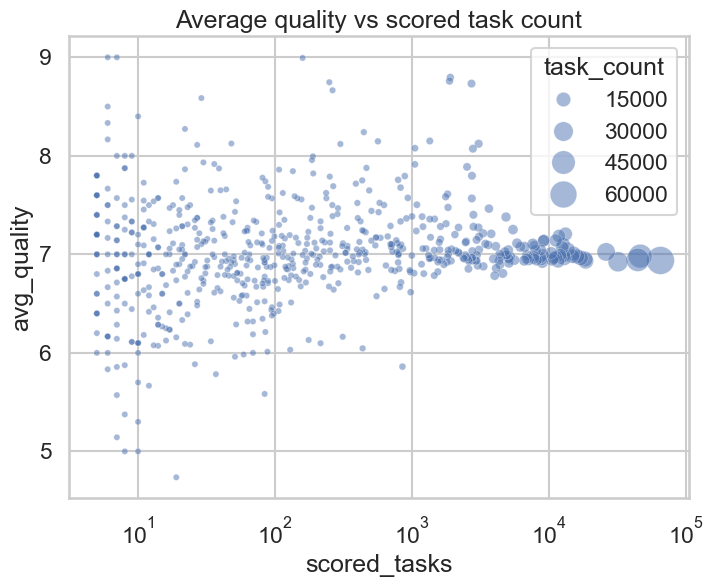

In [4]:
quality_summary = translator_quality_summary(data)
display(quality_summary.head(20))
display(
    quality_summary.query("scored_tasks >= 30")
    .sort_values("avg_quality", ascending=False)
    .head(20)
)

quality_sample = quality_summary.query("scored_tasks >= 5").copy()
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=quality_sample,
    x="scored_tasks",
    y="avg_quality",
    size="task_count",
    alpha=0.5,
    sizes=(20, 400),
)
plt.xscale("log")
plt.title("Average quality vs scored task count")
plt.show()

In [5]:
enriched = load_enriched_tasks()
on_time_summary = translator_on_time_summary(enriched)
display(on_time_summary.head(20))

plt.figure(figsize=(10, 6))
sns.histplot(on_time_summary["on_time_rate"].dropna(), bins=40, color="#ffb703")
plt.title("On-time delivery rate per translator")
plt.show()

MemoryError: Unable to allocate 7.61 MiB for an array with shape (997933,) and data type object

In [ ]:
pair_counts = (
    data.assign(language_pair=data["SOURCE_LANG"] + " -> " + data["TARGET_LANG"])
    .groupby(["TRANSLATOR", "language_pair"])
    .size()
    .rename("pair_tasks")
    .reset_index()
)
pair_coverage = pair_counts.groupby("TRANSLATOR").agg(
    distinct_pairs=("language_pair", "nunique"),
    top_pair_tasks=("pair_tasks", "max"),
    total_pair_tasks=("pair_tasks", "sum"),
)
pair_coverage["top_pair_share"] = pair_coverage["top_pair_tasks"] / pair_coverage["total_pair_tasks"]
pair_coverage["profile_type"] = np.select(
    [
        (pair_coverage["distinct_pairs"] <= 2) | (pair_coverage["top_pair_share"] >= 0.8),
        (pair_coverage["distinct_pairs"] >= 6) & (pair_coverage["top_pair_share"] < 0.5),
    ],
    ["Specialist", "Generalist"],
    default="Mixed",
)
display(pair_coverage["profile_type"].value_counts().rename_axis("profile_type").reset_index(name="translators"))
display(pair_coverage.sort_values("distinct_pairs", ascending=False).head(20))

plt.figure(figsize=(10, 6))
sns.histplot(pair_coverage["distinct_pairs"], bins=30, color="#8338ec")
plt.title("Distinct language pairs per translator")
plt.show()

In [ ]:
joined = join_datasets()
rate_compare = joined.loc[joined["PAIR_HOURLY_RATE"].notna(), ["TRANSLATOR", "HOURLY_RATE", "PAIR_HOURLY_RATE"]].copy()
rate_compare["rate_gap"] = rate_compare["HOURLY_RATE"] - rate_compare["PAIR_HOURLY_RATE"]
display(rate_compare["rate_gap"].describe().to_frame("value"))
display(rate_compare.groupby("TRANSLATOR")["rate_gap"].mean().sort_values(ascending=False).head(20).rename("avg_gap").reset_index())
display(rate_compare.groupby("TRANSLATOR")["rate_gap"].mean().sort_values().head(20).rename("avg_gap").reset_index())

In [ ]:
schedules = schedules.copy()
schedules["WORKING_DAYS_PER_WEEK"] = schedules[["MON", "TUES", "WED", "THURS", "FRI", "SAT", "SUN"]].sum(axis=1)
schedules["WEEKEND_WORKER"] = ((schedules["SAT"] == 1) | (schedules["SUN"] == 1))

shift_start = pd.to_datetime(schedules["START"], format="%H:%M:%S", errors="coerce")
shift_end = pd.to_datetime(schedules["END"], format="%H:%M:%S", errors="coerce")
schedules["SHIFT_START_HOUR"] = shift_start.dt.hour + shift_start.dt.minute / 60
schedules["SHIFT_END_HOUR"] = shift_end.dt.hour + shift_end.dt.minute / 60
schedules["NIGHT_SHIFT"] = schedules["SHIFT_END_HOUR"] <= schedules["SHIFT_START_HOUR"]

display(schedules["WORKING_DAYS_PER_WEEK"].value_counts().sort_index().rename_axis("working_days").reset_index(name="translators"))
display(schedules.loc[schedules["WEEKEND_WORKER"], ["NAME", "START", "END"]].head(25))
display(schedules.loc[schedules["NIGHT_SHIFT"], ["NAME", "START", "END"]].head(25))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(schedules["SHIFT_START_HOUR"].dropna(), bins=24, ax=axes[0], color="#06d6a0")
axes[0].set_title("Shift start hour")
sns.histplot(schedules["SHIFT_END_HOUR"].dropna(), bins=24, ax=axes[1], color="#ef476f")
axes[1].set_title("Shift end hour")
plt.tight_layout()
plt.show()

In [ ]:
tenure = (
    data.groupby("TRANSLATOR")
    .agg(first_task=("START", "min"), last_task=("START", "max"), total_tasks=("TASK_ID", "size"))
    .reset_index()
)
tenure["active_days"] = (tenure["last_task"] - tenure["first_task"]).dt.days
display(tenure.sort_values("active_days", ascending=False).head(20))

plt.figure(figsize=(10, 6))
sns.histplot(tenure["active_days"].dropna(), bins=50, color="#118ab2")
plt.title("Translator active span in days")
plt.show()